In [1]:
import numpy as np

# 加载 .npy 文件
file_path = '/home/lizihao/Work/enzyme_prediction/src/simple2/outputs/v1_pretty/gradient_saliency.npy'
try:
    data = np.load(file_path)
    # 打印数组的基本信息
    print('数组形状:', data.shape)
    print('数组数据类型:', data.dtype)
    # 打印数组内容（前几行示例）
    print('数组内容示例:')
    print(data[:5])  # 打印前 5 个元素，如果是多维数组会打印前几行
except FileNotFoundError:
    print(f"文件 {file_path} 未找到，请检查文件路径是否正确。")
except Exception as e:
    print(f"读取文件时发生错误: {e}")

数组形状: (472422, 33)
数组数据类型: float32
数组内容示例:
[[ 3.25427391e-03 -2.43218336e-03  2.28577107e-03 -1.88851040e-02
   8.77705403e-03 -4.12937775e-02 -9.96858161e-03  1.06908213e-02
  -8.62627197e-03  8.20473302e-03  1.30991535e-02  1.61989536e-02
  -7.15728244e-03 -7.23056495e-03 -4.92426159e-04 -1.83775909e-02
   1.71233974e-02  1.57463867e-02  1.47445444e-02  5.09788888e-03
  -5.29711917e-02 -4.48602485e-03 -1.85108017e-02 -1.48539674e-02
   1.75688528e-02  2.49838065e-02  6.84371698e-05  1.11651411e-02
  -2.24832352e-02 -9.28841811e-03  1.11558230e-03 -3.86061380e-04
  -2.79741664e-03]
 [ 2.81331572e-03 -2.14464683e-03  1.61884644e-03 -1.32382205e-02
   8.61881580e-03 -3.44723612e-02 -6.62348000e-03  7.14760926e-03
  -1.60200195e-03  5.89344278e-03  1.03480145e-02  1.38522573e-02
  -7.99179915e-03 -5.17321844e-03 -5.55404928e-03 -3.56952730e-03
   9.19244438e-03  1.52120693e-02  6.57759141e-03  6.25801971e-03
  -5.96290492e-02 -9.26245935e-03 -9.35495924e-03 -8.28705821e-03
   1.11508537e

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_pca(gradients, save_path):
    pca = PCA(n_components=2)
    reduced_gradients = pca.fit_transform(gradients)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(reduced_gradients[:, 0], reduced_gradients[:, 1], alpha=0.5)
    plt.title('PCA Visualization of Gradient Saliency')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.savefig(save_path)
    plt.close()

    from sklearn.manifold import TSNE

def visualize_tsne(gradients, save_path):
    tsne = TSNE(n_components=2, random_state=42)
    reduced_gradients = tsne.fit_transform(gradients)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(reduced_gradients[:, 0], reduced_gradients[:, 1], alpha=0.5)
    plt.title('t-SNE Visualization of Gradient Saliency')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.savefig(save_path)
    plt.close()
def visualize_feature_importance(gradients, save_path):
    mean_abs_gradients = np.mean(np.abs(gradients), axis=0)
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(mean_abs_gradients)), mean_abs_gradients)
    plt.title('Feature Importance of Gradient Saliency')
    plt.xlabel('Feature Index')
    plt.ylabel('Mean Absolute Gradient')
    plt.savefig(save_path)
    plt.close()

def evaluate(dataset_path, model_path, save_dir="outputs"):
    # ... 原有代码 ...

    # 梯度显著性分析
    gradients = gradient_saliency_analysis(model, loader, device)
    np.save(os.path.join(save_dir, "gradient_saliency.npy"), gradients.numpy())
    print(f"✅ Gradient saliency analysis saved to {save_dir}/gradient_saliency.npy")

    # 加载梯度数据
    gradients = np.load(os.path.join(save_dir, "gradient_saliency.npy"))

    # 调用可视化函数
    visualize_pca(gradients, os.path.join(save_dir, "pca_gradient_saliency.png"))
    print(f"✅ PCA visualization saved to {save_dir}/pca_gradient_saliency.png")

    visualize_tsne(gradients, os.path.join(save_dir, "tsne_gradient_saliency.png"))
    print(f"✅ t-SNE visualization saved to {save_dir}/tsne_gradient_saliency.png")

    visualize_feature_importance(gradients, os.path.join(save_dir, "feature_importance_gradient_saliency.png"))
    print(f"✅ Feature importance visualization saved to {save_dir}/feature_importance_gradient_saliency.png")

    # ... 原有代码 ...

/tmp/ipykernel_2494286/412175635.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = torch.load("../data/processed/dataset_v1_nopqr.pt")[0]


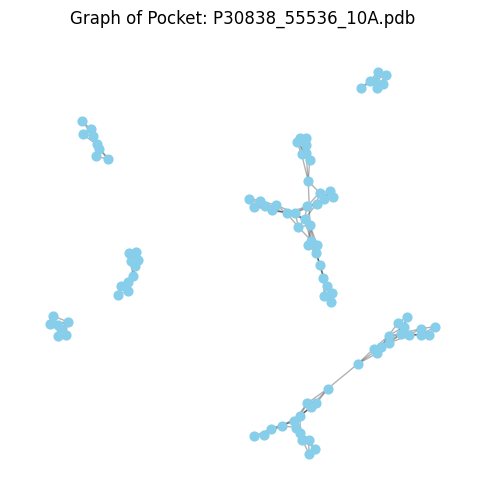

In [4]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

# 假设你已经加载了一个 sample
sample = torch.load("../data/processed/dataset_v1_nopqr.pt")[0]

# 转换为 NetworkX 图（无向图更适合可视化）
G = to_networkx(sample, to_undirected=True)

# 可选布局（spring布局模拟分子结构感）
pos = nx.spring_layout(G, seed=42)

# 可视化
plt.figure(figsize=(6,6))
nx.draw_networkx_nodes(G, pos, node_size=40, node_color='skyblue')
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title(f'Graph of Pocket: {sample.pdb_id}')
plt.axis('off')
plt.show()


In [ ]:
#y_pred
[tensor([[ 0.6315, -3.7866],
        [ 0.1497, -4.2811],
        [ 0.4961, -3.7497],
        [ 0.4169, -3.7502],
        [ 0.3220, -4.1910],
        [ 0.3958, -3.8718],
        [-0.0338, -4.3705],
        [ 1.0647, -4.0391],
        [ 0.7665, -4.1131],
        [ 0.9306, -2.4741],
        [ 0.9306, -2.4741],
        [ 0.5023, -1.4198],
        [ 0.8556, -2.7814],
        [ 1.6172, -3.3174],
        [ 0.6682, -3.9383],
        [ 0.2957, -4.1746],
        [ 2.0282, -3.4908],
        [ 1.8854, -4.0357],
        [ 1.8854, -4.0357],
        [ 2.0282, -3.4908],
        [ 1.1679, -4.6706],
        [ 0.5572, -5.0587],
        [ 0.6399, -5.1033],
        [ 1.1679, -4.6706],
        [ 0.6399, -5.1033],
        [ 0.6399, -5.1033],
        [ 0.6399, -5.1033],
        [ 0.6399, -5.1033],
        [ 1.1227, -1.7400],
        [ 0.6399, -5.1033],
        [ 0.6399, -5.1033],
        [-1.2951, -3.5493]])]

In [ ]:
#y_true
[tensor([9.0000e-01, 1.1390e-04, 1.6000e+00, 3.8000e-05, 2.0000e+00, 3.5000e-05,
        2.5000e+00, 2.7000e-05, 1.1300e+01, 3.0000e-05, 3.6000e+00, 2.6000e-04,
        2.1000e+00, 9.0000e-06, 1.0300e+01, 1.0000e-05, 3.4000e+00, 5.0000e-04,
        2.4900e+01, 6.9000e-03, 2.4900e+01, 6.9000e-03, 3.0500e+02, 9.1000e-04,
        8.0000e+00, 1.1000e-03, 2.9000e+01, 2.6000e-04, 1.0200e+02, 1.4900e-04,
        1.0200e+02, 5.7000e-06, 1.1750e+02, 8.1580e-04, 1.1750e+02, 2.0500e-05,
        1.1750e+02, 2.0500e-05, 1.1750e+02, 8.1580e-04, 1.1000e+01, 1.1800e-05,
        4.0000e+00, 4.0000e-06, 6.0550e+00, 9.9000e-06, 1.1000e+01, 1.1800e-05,
        6.0550e+00, 9.9000e-06, 6.0550e+00, 9.9000e-06, 6.0550e+00, 9.9000e-06,
        6.0550e+00, 9.9000e-06, 4.7300e+01, 7.2400e-02, 6.0550e+00, 9.9000e-06,
        6.0550e+00, 9.9000e-06, 1.1000e-01, 2.8600e-05])]